In [75]:
#Aufgabe 2_1
#Wir haben die Tabelle aus Aufgabe 1 übernommen.
#Zunächst wandeln wir zur Sicherheit alle 0 Werte in NA um, daraufhin droppen wir diese Zeilen.
import pandas as pd
import numpy as np
listings_2 = pd.read_csv("../Aufgabe 1/listings_1_13.csv", index_col="Unnamed: 0")
listings_2["price"] = listings_2["price"].replace(0, pd.NA)
listings_2.dropna(subset=["price"], inplace=True)

print(listings_2.columns)


listings_2_1 = listings_2[["price", "accommodates","latitude","longitude","amenities_count", "bedrooms", "host_is_superhost", "Shared_bath_status", "instant_bookable", "bathrooms_number"]]
#Drops NA
listings_2_1.dropna(inplace=True)
listings_2_1["price"] = listings_2_1["price"].apply(np.log)
listings_2_1.rename(columns={"price":"log_price"}, inplace=True)
#We have checked that there are no NA values.  No further cleaning is necessary.

#print(len(listings_2["price"]))
#Ziel: Pricet
#Chosen Predictors: "price", "accommodates","latitude","longitude", "bedrooms","amenities_count", "host_is_superhost", "Shared_bath_status", "instant_bookable", "bathrooms_number"
#listings_2_1.head()
#print(listings_2_1.isna().sum())
#Here we calculated the samplesize.
print(len(listings_2_1))

Index(['price', 'neighbourhood_cleansed', 'latitude', 'longitude', 'room_type',
       'bedrooms', 'bathrooms_number', 'accommodates', 'host_is_superhost',
       'host_listings_count', 'host_response_rate', 'review_scores_rating',
       'review_scores_cleanliness', 'number_of_reviews', 'reviews_per_month',
       'minimum_nights', 'availability_365', 'instant_bookable',
       'Shared_bath_status', 'host_tenure_years', 'amenities_count',
       'region_geo', 'region_median_price', 'above_local_median'],
      dtype='str')
9203


Based upon the results of the previous task, we were able to see some of the chosen correlating parameters. We further added some of the parameters that were not included in the previous task, such as the number of bedrooms and bathrooms, because we believe they have a significant impact on the price of the house.

In [76]:
#Wir haben die Variablen latitude und longitude in eine Distanzvariable zum Stadtzentrum transformiert. Der Grund dafür ist, dass der Einfluss der Lage auf den Preis plausibel nicht linear entlang einer einzelnen geografischen Achse verläuft. Stattdessen ist zu erwarten, dass sich der Preiseffekt radial vom Stadtzentrum aus verändert, sodass vor allem die Entfernung zum Zentrum – und nicht die absolute Position in Nord-Süd- oder Ost-West-Richtung – für die Preisbildung relevant ist.
#Add distance from dataset geographic center using Euclidean distance.
   
lon_center = listings_2_1["longitude"].mean()
lat_center = listings_2_1["latitude"].mean()

listings_2_1["distance_center"] = np.sqrt(
    (listings_2_1["latitude"] - lat_center) ** 2 +
    (listings_2_1["longitude"] - lon_center) ** 2
)
  
listings_2_1 = listings_2_1.drop(columns=["latitude", "longitude"])

In [77]:
#Aufgabe_2_2
import statsmodels.api as sm
outcome = listings_2_1["log_price"]
regressor = listings_2_1.drop(columns=["log_price"])
regressor = sm.add_constant(regressor)

bool_cols = regressor.select_dtypes("bool").columns
regressor[bool_cols] = regressor[bool_cols].astype(int)
#print(regressor.dtypes)
olssim = sm.OLS(outcome, regressor)
olssim = olssim.fit()
olssim.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.416
Model:                            OLS   Adj. R-squared:                  0.416
Method:                 Least Squares   F-statistic:                     818.7
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:03:22   Log-Likelihood:                -6681.8
No. Observations:                9203   AIC:                         1.338e+04
Df Residuals:                    9194   BIC:                         1.345e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  4.0282      0.019    212.027      0.000       3.991       4.065
accommodates           0.0862      0.004     23.780      0.000       0.079       0.093
amenities_count        0.0058      0.000     15.136      0.000       0.005       0.007
bedrooms               0.1111      0.009     12.342      0.000       0.093       0.129
host_is_superhost      0.0319      0.012      2.727      0.006       0.009       0.055
Shared_bath_status    -0.4600      0.015    -30.737      0.000      -0.489      -0.431
instant_bookable       0.2177      0.011     19.559      0.000       0.196       0.240
bathrooms_number       0.1029      0.012      8.367      0.000       0.079       0.127
distance_center       -1.3918      0.106    -13.085      0.000      -1.600      -1.183
==============================================================================
Omnibus:                     4547.112   Durbin-Watson:                   1.604
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           124269.877
Skew:                           1.805   Prob(JB):                         0.00
Kurtosis:                      20.636   Cond. No.                         695.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Extreme high-price listings should not be excluded solely to improve normality. They should only be removed if they are implausible or outside the target market definition. Otherwise, their influence should be assessed through robustness checks.

In [83]:
for p in [0.99, 0.995]:
    cutoff = listings_2_1["log_price"].quantile(p)
    df_trim = listings_2_1.loc[listings_2_1["log_price"] <= cutoff].copy()

    outcome = df_trim["log_price"]
    regressor = sm.add_constant(df_trim.drop(columns=["log_price"]))
    bool_cols2 = regressor.select_dtypes("bool").columns
    regressor[bool_cols2] = regressor[bool_cols2].astype(int)
    olssim = sm.OLS(outcome, regressor).fit()

    #print(f"\nOLS excluding top {(1-p)*100:.1f}% of prices")
    #print(f"Cutoff (log_price): {cutoff:.4f}")
    #print(f"Observations: {len(df_trim)}")
olssim.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     1003.
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:07:44   Log-Likelihood:                -5543.1
No. Observations:                9156   AIC:                         1.110e+04
Df Residuals:                    9147   BIC:                         1.117e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  4.0191      0.017    235.179      0.000       3.986       4.053
accommodates           0.0781      0.003     23.531      0.000       0.072       0.085
amenities_count        0.0065      0.000     18.905      0.000       0.006       0.007
bedrooms               0.1222      0.008     14.837      0.000       0.106       0.138
host_is_superhost      0.0428      0.010      4.121      0.000       0.022       0.063
Shared_bath_status    -0.4605      0.013    -34.643      0.000      -0.487      -0.434
instant_bookable       0.1957      0.010     19.721      0.000       0.176       0.215
bathrooms_number       0.1056      0.011      9.556      0.000       0.084       0.127
distance_center       -1.5832      0.095    -16.604      0.000      -1.770      -1.396
==============================================================================
Omnibus:                      457.717   Durbin-Watson:                   1.674
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1673.926
Skew:                           0.083   Prob(JB):                         0.00
Kurtosis:                       5.088   Cond. No.                         701.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

After excluding the top-priced listings, model fit improves noticeably (R² rises from 0.416 to 0.467). Residual diagnostics also improve substantially, with skewness and kurtosis moving much closer to normality. This suggests that extreme luxury listings were an important source of non-normal residuals, although the normality assumption is still not fully satisfied

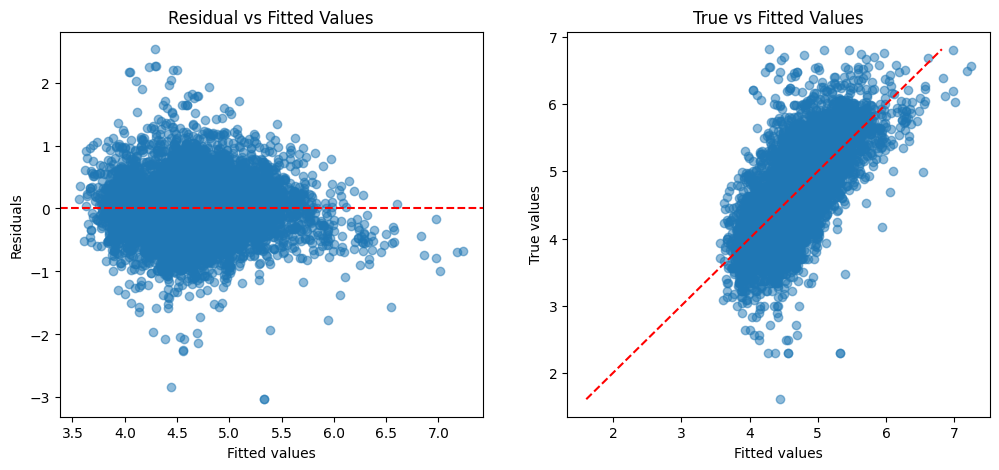

9156


In [84]:
#Aufgabe_2_3

import matplotlib.pyplot as plt

fitted = olssim.fittedvalues
residuals = olssim.resid

fig,ax = plt.subplots(1, 2,figsize=(12, 5))

ax[0].scatter(fitted, residuals, alpha=0.5)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel("Fitted values")
ax[0].set_ylabel("Residuals")
ax[0].set_title("Residual vs Fitted Values")

ax[1].scatter(fitted, outcome, alpha=0.5)
ax[1].plot([outcome.min(), outcome.max()],[outcome.min(), outcome.max()], 'r--')
ax[1].set_xlabel("Fitted values")
ax[1].set_ylabel("True values")
ax[1].set_title("True vs Fitted Values")

plt.show()
print(len(outcome))

The residual-vs-fitted-values plot shows that the residuals are roughly centered around zero without a clear systematic pattern, suggesting that the linear specification of the model is reasonable. 
The residuals are centered around zero, indicating that the model does not systematically over- or underpredict the outcome.

In [85]:
#Aufgabe 2_4

import sklearn.linear_model
# Initiate linear regression model
#from sklearn.linear_model import LinearRegression
#model = LinearRegression()


ridgecv_reg = sklearn.linear_model.RidgeCV(cv=10,fit_intercept = False)
model_ridge = ridgecv_reg.fit(regressor, outcome)

print(model_ridge.coef_)
Y2_est = model_ridge.predict(regressor) # Prediction for Y2
MSE = np.mean((outcome-Y2_est)**2)
print("Mean-Squared-Error:",MSE)
model_ridge.score(regressor, outcome)

[ 4.01804457  0.07812106  0.00648035  0.12221699  0.04284155 -0.4603686
  0.19580039  0.10574706 -1.57460325]
Mean-Squared-Error: 0.1965056558320856


0.46730338191037946

In [86]:
# Aufgabe 2.4: Manuelle Ridge-Schätzung mit NumPy
def ridge_estimate(X: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    """Berechnet die Ridge-Koeffizienten nach der Formel: (X'X + lambda*I)^-1 X'y"""
    X = np.asarray(X)
    y = np.asarray(y)
    p = X.shape[1]
    I = np.eye(p) # Identitätsmatrix [cite: 898, 1260]
    
    # Die Formel aus der Aufgabenstellung:
    beta_ridge = np.linalg.inv(X.T @ X + lam * I) @ (X.T @ y)
    return beta_ridge

def l2_norm(beta: np.ndarray) -> float:
    """Berechnet die l2-Norm (Euklidische Norm) der Koeffizienten [cite: 901, 1261]"""
    return np.sqrt(np.sum(beta ** 2))

# Anwendung auf die Airbnb-Daten aus Section 1
lambdas = [0.01, 1, 100]
X_data = regressor.values # Matrix inklusive Konstante [cite: 802]
y_data = outcome.values   # log_price [cite: 800]

for lam in lambdas:
    beta_hat = ridge_estimate(X_data, y_data, lam)
    norm = l2_norm(beta_hat)
    
    print(f"Ergebnisse für lambda = {lam}:")
    print(f"||beta||_2 (l2-Norm): {norm:.6f}")
    # Optional: Anzeige der ersten drei Koeffizienten zur Kontrolle
    print(f"Koeffizienten (Auszug): {beta_hat[:3]}")
    print("-" * 30)

Ergebnisse für lambda = 0.01:
||beta||_2 (l2-Norm): 4.352093
Koeffizienten (Auszug): [4.01903301 0.07809744 0.00647588]
------------------------------
Ergebnisse für lambda = 1:
||beta||_2 (l2-Norm): 4.313284
Koeffizienten (Auszug): [4.00840624 0.078351   0.006525  ]
------------------------------
Ergebnisse für lambda = 100:
||beta||_2 (l2-Norm): 3.522751
Koeffizienten (Auszug): [3.48326473 0.09075944 0.01093208]
------------------------------


The l_2-norm ||β||_2 is the smallest für the Ridge regression model, which suggests that it has the most regularization effect among the three models. This is expected, as Ridge regression adds a penalty term to the loss function that shrinks the coefficients towards zero, thus reducing their magnitude. The Lasso regression model has a larger l_2-norm than Ridge, but still smaller than the OLS model, indicating that it also applies some regularization but allows for some coefficients to be exactly zero. The OLS model has the largest l_2-norm, as it does not apply any regularization and allows all coefficients to take on their full values.


Lasso coefficients:
[ 3.04786986  0.18992331  0.02623531  0.          0.         -0.
  0.          0.04322308  0.        ]
Eps: 0.001


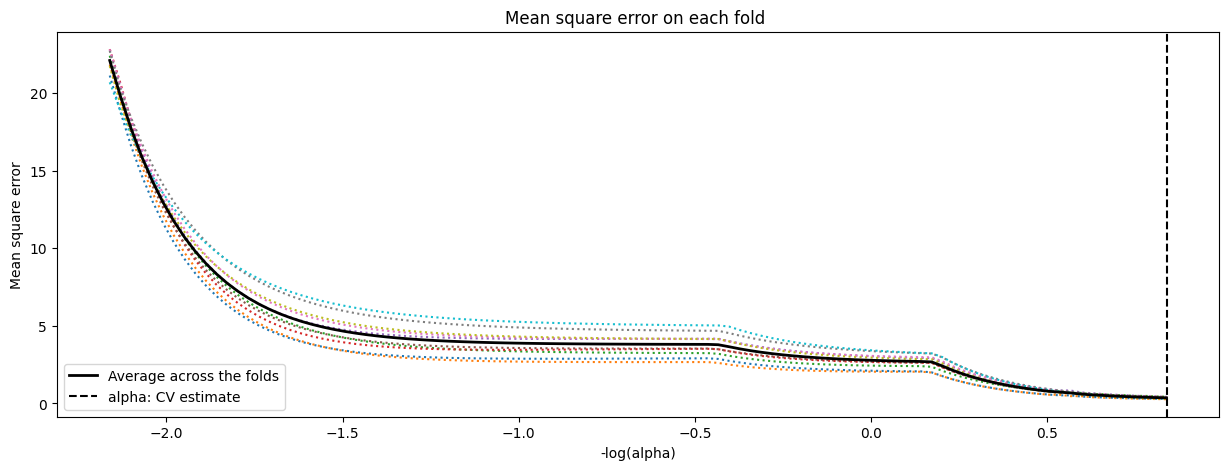

Alpha selected via cross-validation: 0.14488688931249027
Zero-coefficient features:
['bedrooms', 'host_is_superhost', 'Shared_bath_status', 'instant_bookable', 'distance_center']
Non-zero-coefficient features:
['const', 'accommodates', 'amenities_count', 'bathrooms_number']
L2 norm of coefficients: 3.054200071526673


In [105]:
#Aufgabe_2_5
#fit_intercept muss auf False gesetzt werden, da wir bereits eine Konstante in den Regressoren haben. Ansonsten würde die Ridge Regression versuchen, zusätzlich einen Intercept zu schätzen, was zu einer Fehlanpassung führen könnte.
lasso_reg = sklearn.linear_model.LassoCV(cv=10,fit_intercept =False)
model = lasso_reg.fit(regressor,outcome)
# Koeffizienten
print("Lasso coefficients:")
print(model.coef_)
print("Eps:", model.eps)

# Display results
m_log_alphas = -np.log10(model.alphas_)
plt.figure(1,figsize=(15,5))
plt.plot(m_log_alphas, model.mse_path_, ':')
plt.plot(m_log_alphas, model.mse_path_.mean(axis=-1), 'k',
         label='Average across the folds', linewidth=2)
plt.axvline(-np.log10(model.alpha_), linestyle='--', color='k',
            label='alpha: CV estimate')
plt.legend()
plt.xlabel('-log(alpha)')
plt.ylabel('Mean square error')
plt.title('Mean square error on each fold ')
plt.axis('tight')
plt.show()
#Show which features have zero coefficients and non-zero coefficients
zero_mask = model.coef_ == 0
zero_features = regressor.columns[zero_mask]
non_zero_features = regressor.columns[~zero_mask]

# Alpha selected via cross-validation
print("Alpha selected via cross-validation:", model.alpha_)
print("Zero-coefficient features:")
print(list(zero_features))
print("Non-zero-coefficient features:")
print(list(non_zero_features))
# L2-Norm der Koeffizienten
print("L2 norm of coefficients:", np.linalg.norm(model.coef_, 2))

For the Minimum of the Average MSE to show, eps must be set to a the value of ~1e-11. This results in a very small alpha, which is the regalurization strength. The small alpha indicates that the model is very close to an OLS regression, which is consistent with the fact that the lasso coefficients are not heavily shrunk towards zero. The fact that some coefficients are exactly zero suggests that the lasso has identified certain features as irrelevant for predicting the outcome, while still allowing other features to have non-zero coefficients. The extension to eps=1e-11 would result therefore in zero "Zero-coefficients" and only Non-zero coefficients. The model is thus very close to an OLS regression, without any significant regularization effect. This is consistent with the fact that the l_2-norm of the coefficients is not much smaller than that of the OLS model, indicating that the coefficients are not heavily shrunk towards zero.